# Beispiele

## Beispiel: Generate Numbers

<div>
    <img src=attachment:3f08eada-371e-4112-b6e8-42850c3f7895.png width=300>
</div>

Nutzen Sie den `load_digits` Datensatz aus `sklearn.datasets`, um mittels eines _Gaussian Mixture Models_ eine Funktion zu bauen, die Ihnen neue - durch das Modell generierte - "handschriftliche" Zahlen generiert. Hier nutzen wir die Eigenschaft von GMMs aus, dass sie probabilistisch bzw. generativ sind.
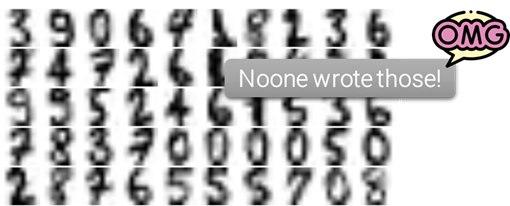

In [1]:
# Import
from sklearn.datasets import load_digits
from sklearn.mixture import GaussianMixture
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import numpy as np
data = load_digits().data

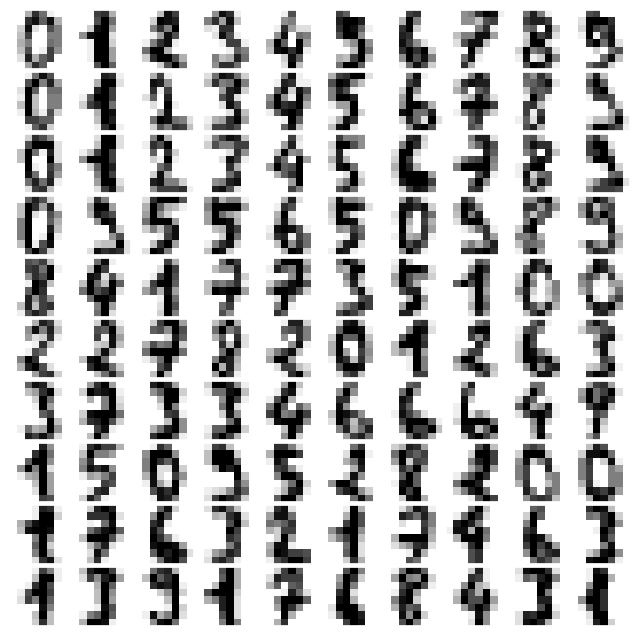

In [2]:
def plot_digits(data):
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        im.set_clim(0, 16)
plot_digits(data)

In [3]:
# Write loop training models for a range of components

# Get AICs for each model

# Plot AICs


In [4]:
# Use a good number of components

# See, if it converged


In [5]:
# Generate new digits


In [6]:
# Plot them


### Lösung

In [7]:
# Import
from sklearn.datasets import load_digits
from sklearn.mixture import GaussianMixture
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import numpy as np
data = load_digits().data

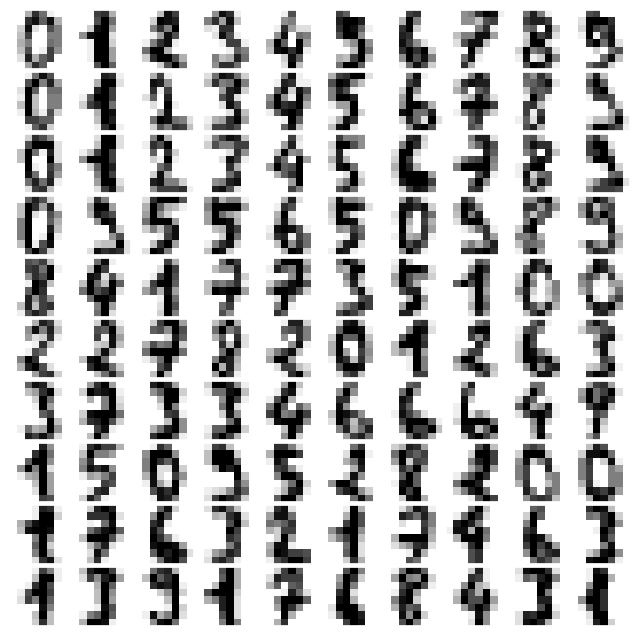

In [8]:
def plot_digits(data):
    fig, ax = plt.subplots(10, 10, figsize=(8, 8),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, axi in enumerate(ax.flat):
        im = axi.imshow(data[i].reshape(8, 8), cmap='binary')
        im.set_clim(0, 16)
plot_digits(data)

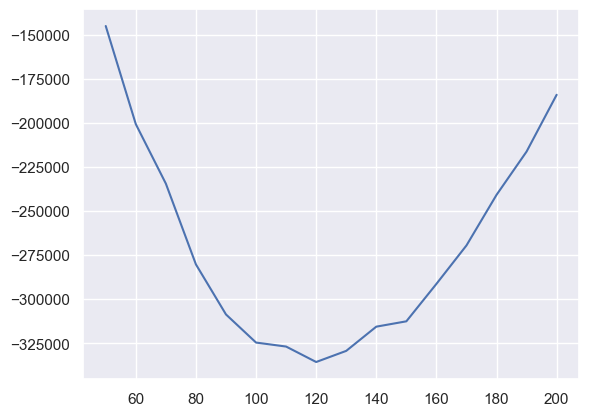

In [9]:
# Write loop training models for a range of components
n_components = np.arange(50, 210, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=0)
          for n in n_components]

# Get AICs for each model
aics = [model.fit(data).aic(data) for model in models]

# Plot AICs
plt.plot(n_components, aics);

In [10]:
# Use a good number of components
gmm = GaussianMixture(120, covariance_type='full', random_state=0)
gmm.fit(data)

# See, if it converged
print(gmm.converged_)

True


In [11]:
# Generate new digits
data_new,_ = gmm.sample(100)
data_new.shape

(100, 64)

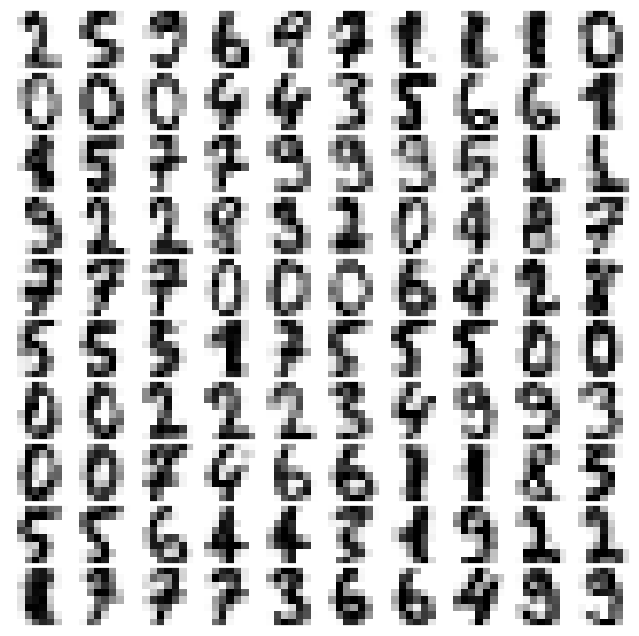

In [12]:
# Plot them
plot_digits(data_new)